In [2]:
import polars as pl
from datetime import datetime, timezone

In [3]:
# Carrega o dataset original
df = pl.read_parquet("features/ml_features_v3.parquet")

print(df.shape)
df.columns

(5587547, 23)


['market_id',
 'minute_bar',
 'close_mid',
 'mean_spread',
 'close_spread',
 'bar_volatility',
 'total_volume',
 'buy_volume',
 'sell_volume',
 'trade_count',
 'order_flow_imbalance',
 'target',
 'return_1m',
 'bid_depth',
 'ask_depth',
 'depth_imbalance',
 'ofi_corrected',
 'close_mid_lag1',
 'depth_imbalance_lag1',
 'mean_spread_lag1',
 'close_spread_lag1',
 'bar_volatility_lag1',
 'ofi_corrected_lag1']

# Etapa 1 - Separação temporal dos dados

### Objetivo:

Como o problema consiste em prever se o preço de um contrato irá subir nos próximos 15 minutos, a divisão entre treino e teste deve respeitar a ordem cronológica dos dados.

Diferentemente de problemas tabulares tradicionais, em séries temporais não é adequado embaralhar as observações, pois isso permitiria que o modelo utilizasse informações futuras durante o treinamento (data leakage).

Assim, o conjunto de dados foi dividido da seguinte forma:

- Treino: 06/03/2026 até 09/03/2026
- Teste: 10/03/2026 até 11/03/2026

Essa estratégia simula um cenário real de previsão, no qual o modelo aprende apenas com informações disponíveis até determinado instante e é avaliado em dados futuros.

In [4]:
# Conjunto de treino
train = df.filter(
    pl.col("minute_bar") < datetime(2026, 3, 10, tzinfo=timezone.utc)
)

# Conjunto de teste
test = df.filter(
    pl.col("minute_bar") >= datetime(2026, 3, 10, tzinfo=timezone.utc)
)

print("Treino:", train.shape)
print("Teste :", test.shape)

Treino: (4948403, 23)
Teste : (639144, 23)


A soma dos tamanhos das datas bateram 

Agora vou verificar o intevalo:


In [5]:
print(
    train.select(
        pl.min("minute_bar").alias("início"),
        pl.max("minute_bar").alias("fim")
    )
)

print(
    test.select(
        pl.min("minute_bar").alias("início"),
        pl.max("minute_bar").alias("fim")
    )
)

shape: (1, 2)
┌─────────────────────────┬─────────────────────────┐
│ início                  ┆ fim                     │
│ ---                     ┆ ---                     │
│ datetime[μs, UTC]       ┆ datetime[μs, UTC]       │
╞═════════════════════════╪═════════════════════════╡
│ 2026-03-06 00:00:00 UTC ┆ 2026-03-09 23:59:00 UTC │
└─────────────────────────┴─────────────────────────┘
shape: (1, 2)
┌─────────────────────────┬─────────────────────────┐
│ início                  ┆ fim                     │
│ ---                     ┆ ---                     │
│ datetime[μs, UTC]       ┆ datetime[μs, UTC]       │
╞═════════════════════════╪═════════════════════════╡
│ 2026-03-10 00:00:00 UTC ┆ 2026-03-11 23:59:00 UTC │
└─────────────────────────┴─────────────────────────┘


Bateu certinho também

### Os mercados presentes no conjunto de teste já apareceram durante o treinamento?

In [6]:
train_markets = set(train["market_id"].unique().to_list())
test_markets = set(test["market_id"].unique().to_list())

common = train_markets & test_markets

print(f"Mercados no treino: {len(train_markets)}")
print(f"Mercados no teste : {len(test_markets)}")
print(f"Mercados em comum : {len(common)}")
print(f"Percentual em comum: {100 * len(common) / len(test_markets):.2f}%")

Mercados no treino: 4070
Mercados no teste : 1502
Mercados em comum : 862
Percentual em comum: 57.39%


Após a divisão temporal dos dados, foi analisada a sobreposição de mercados entre os conjuntos de treino e teste.

Observa-se que **862 mercados (57,39%) presentes no conjunto de teste também aparecem no conjunto de treino**, permitindo que o modelo aprenda seu comportamento histórico antes de realizar previsões futuras.

Por outro lado, **640 mercados (42,61%) aparecem apenas no conjunto de teste**. Isso significa que, além de prever a evolução temporal de mercados já conhecidos, o modelo também precisará generalizar seu aprendizado para contratos nunca vistos durante o treinamento.

Esse cenário torna a avaliação mais desafiadora, mas também mais próxima de uma situação real, na qual novos mercados podem surgir continuamente na plataforma. Para os mercados que só aparecem no conjunto de teste é esperado um desempenho menor.

Com isso podemos analisar duas coisas:
- Prever o futuro de mercados já conhecidos
- Prever mercados inéditos 

### Distribuição do target

Vimos na análise exploratória que o target está desbalanceado, vamos ver se nessa divisão temporal que fizemos vamos ter nosso teste com 90% de classe 0 ou o treino com 90% de classe 0, isso seria um problema

In [7]:
# Treino

train.group_by("target").len().with_columns(
    (
        pl.col("len") / train.height * 100
    ).alias("percentual")
)

target,len,percentual
i8,u32,f64
0,3630505,73.367206
1,1317898,26.632794


In [8]:
# Teste

test.group_by("target").len().with_columns(
    (
        pl.col("len") / test.height * 100
    ).alias("percentual")
)

target,len,percentual
i8,u32,f64
0,467953,73.215582
1,171191,26.784418


Após a divisão temporal do conjunto de dados, foi analisada a distribuição da variável target nos conjuntos de treino e teste.

| Conjunto | Classe 0 | Classe 1 |
|-----------|----------:|----------:|
| Treino | 73,37% | 26,63% |
| Teste | 73,22% | 26,78% |


Observa-se que a proporção das classes permaneceu praticamente inalterada entre os conjuntos de treino e teste, apresentando uma diferença inferior a **0,2 ponto percentual**.

Isso indica que a divisão temporal preservou adequadamente o desbalanceamento natural do problema, permitindo que o desempenho dos modelos seja avaliado em condições semelhantes às encontradas durante o treinamento.

Apesar dessa consistência, o problema continua sendo desbalanceado, com aproximadamente **73% das observações pertencendo à classe 0** (o preço não sobe nos próximos 15 minutos). Dessa forma, métricas como Precisão, Recall, F1-score e ROC-AUC serão mais adequadas para avaliar o desempenho dos modelos do que a acurácia isoladamente.

### Excluir os nulls dos Lags:

In [9]:
lag_cols = [
    "close_mid_lag1",
    "depth_imbalance_lag1",
    "mean_spread_lag1",
    "close_spread_lag1",
    "bar_volatility_lag1",
    "ofi_corrected_lag1"
]

train.select(
    [pl.col(c).is_null().sum().alias(c) for c in lag_cols]
)


close_mid_lag1,depth_imbalance_lag1,mean_spread_lag1,close_spread_lag1,bar_volatility_lag1,ofi_corrected_lag1
u32,u32,u32,u32,u32,u32
4070,4070,4070,4070,4070,4070


In [10]:
test.select(
    [pl.col(c).is_null().sum().alias(c) for c in lag_cols]
)

close_mid_lag1,depth_imbalance_lag1,mean_spread_lag1,close_spread_lag1,bar_volatility_lag1,ofi_corrected_lag1
u32,u32,u32,u32,u32,u32
640,640,640,640,640,640


Foi realizada uma verificação da quantidade de valores ausentes nas variáveis de defasagem criadas durante a etapa de engenharia de atributos.

- Conjunto de treino:

Todas as variáveis de lag apresentaram **4.070 valores nulos**, correspondendo exatamente ao número de mercados presentes no conjunto de treino. Esse comportamento é esperado, pois a primeira observação de cada mercado não possui um registro anterior para servir como referência.

- Conjunto de teste:

No conjunto de teste, todas as variáveis de lag apresentaram **640 valores nulos**.

Esse número coincide exatamente com a quantidade de mercados que aparecem **pela primeira vez** no período de teste. Já os **862 mercados presentes tanto no treino quanto no teste** mantiveram suas informações históricas, permitindo que a primeira observação do período de teste utilizasse como lag a última observação disponível no conjunto de treino.

### Remover os nulls 
Como eles existem apenas nas variáveis de lag, podemos remover somente as linhas que possuem null nessas colunas.

In [11]:
lag_cols = [
    "close_mid_lag1",
    "depth_imbalance_lag1",
    "mean_spread_lag1",
    "close_spread_lag1",
    "bar_volatility_lag1",
    "ofi_corrected_lag1"
]

train = train.drop_nulls(lag_cols)
test = test.drop_nulls(lag_cols)

### Definição das features

- O que não entra?

```
market_id
```
É apenas um identificador.

Se colocarmos no modelo, ele tentará aprender "nomes de mercados", o que não faz sentido.
```
minute_bar
```
Também não entra diretamente.

Embora seja uma informação temporal, o timestamp bruto não possui significado numérico útil para a Regressão Logística. Se quiséssemos explorar efeitos sazonais (hora do dia, dia da semana etc.), criaríamos novas features específicas.

```
total_ volume, buy_volume, sell_volume, trade_count
```
Na análise exploratória a importância dessas variáveis demonstraram baixo poder preditivo em relação ao target

```
bid_depth, ask_depth
```
Elas apareceram como features importantes, mas depth_imabalance é feito a partir delas. Por elas serem muito relacionadas, em um modelo linear, isso pode introduzir multicolinearidade, tornando os coeficientes mais instáveis e dificultando a interpretação.

Posso testar inserir depois

In [12]:
features = [
    "close_mid",
    "depth_imbalance",
    "mean_spread",
    "close_spread",
    "bar_volatility",
    "ofi_corrected",

    "close_mid_lag1",
    "depth_imbalance_lag1",
    "mean_spread_lag1",
    "close_spread_lag1",
    "bar_volatility_lag1",
    "ofi_corrected_lag1"
]

In [13]:
X_train = train.select(features)
y_train = train["target"]

X_test = test.select(features)
y_test = test["target"]

### O que o TimeSeriesSplit faz 

Ele simula algo muito mais próximo do mundo real:

em vez de 1 teste → vários testes ao longo do tempo

Ele cria vários cenários assim:

Fold 1:
- treino: início da série
- teste: próximo bloco no tempo

Fold 2:
- treino: início + Fold 1
- teste: próximo bloco

Fold 3:
- treino: mais histórico
- teste: mais à frente

Este pipeline tem como objetivo treinar e avaliar um modelo de Regressão Logística para previsão da direção do preço em 15 minutos, utilizando validação temporal e teste holdout.

O processo é dividido em duas etapas:
- Validação interna com TimeSeriesSplit
- Avaliação final em conjunto holdout separado por data

In [14]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

In [15]:
tscv = TimeSeriesSplit(n_splits=5)

auc_scores = []
f1_scores = []
precision_scores = []
recall_scores = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):

    print(f"\n===== FOLD {fold + 1} =====")

    # ------------------------
    # Split temporal interno (POLARS SAFE)
    # ------------------------
    X_tr = X_train[train_idx]
    X_val = X_train[val_idx]

    y_tr = y_train[train_idx]
    y_val = y_train[val_idx]

    # ------------------------
    # Converter para numpy (sklearn compatível)
    # ------------------------
    X_tr_np = X_tr.to_numpy()
    X_val_np = X_val.to_numpy()

    y_tr_np = y_tr.to_numpy().ravel()
    y_val_np = y_val.to_numpy().ravel()

    # ------------------------
    # Scaling (evita leakage)
    # ------------------------
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr_np)
    X_val_scaled = scaler.transform(X_val_np)

    # ------------------------
    # Modelo
    # ------------------------
    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr_scaled, y_tr_np)

    # ------------------------
    # Predição
    # ------------------------
    y_pred = model.predict(X_val_scaled)
    y_proba = model.predict_proba(X_val_scaled)[:, 1]

    # ------------------------
    # Métricas
    # ------------------------
    auc = roc_auc_score(y_val_np, y_proba)
    f1 = f1_score(y_val_np, y_pred)
    precision = precision_score(y_val_np, y_pred)
    recall = recall_score(y_val_np, y_pred)

    auc_scores.append(auc)
    f1_scores.append(f1)
    precision_scores.append(precision)
    recall_scores.append(recall)

    print(f"AUC: {auc:.4f}")
    print(f"F1: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")


===== FOLD 1 =====
AUC: 0.8811
F1: 0.6388
Precision: 0.7385
Recall: 0.5627

===== FOLD 2 =====
AUC: 0.8790
F1: 0.5954
Precision: 0.7223
Recall: 0.5064

===== FOLD 3 =====
AUC: 0.8926
F1: 0.6426
Precision: 0.7881
Recall: 0.5424

===== FOLD 4 =====
AUC: 0.8890
F1: 0.5975
Precision: 0.6742
Recall: 0.5365

===== FOLD 5 =====
AUC: 0.8921
F1: 0.6243
Precision: 0.7517
Recall: 0.5337


In [16]:
print("\n===== VALIDAÇÃO TEMPORAL (TIME SERIES SPLIT) =====")

print(f"AUC médio: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"F1 médio: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"Precision médio: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall médio: {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")


===== VALIDAÇÃO TEMPORAL (TIME SERIES SPLIT) =====
AUC médio: 0.8868 ± 0.0057
F1 médio: 0.6197 ± 0.0200
Precision médio: 0.7350 ± 0.0374
Recall médio: 0.5363 ± 0.0181


In [17]:
scaler_final = StandardScaler()

X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [18]:
y_pred_test = final_model.predict(X_test_scaled)
y_proba_test = final_model.predict_proba(X_test_scaled)[:, 1]

In [19]:
print("\n===== HOLDOUT FINAL (TESTE REAL) =====")

print("ROC-AUC:", roc_auc_score(y_test, y_proba_test))
print("F1:", f1_score(y_test, y_pred_test))
print("Precision:", precision_score(y_test, y_pred_test))
print("Recall:", recall_score(y_test, y_pred_test))


===== HOLDOUT FINAL (TESTE REAL) =====
ROC-AUC: 0.8942137259394847
F1: 0.6271580168522166
Precision: 0.6019461343575013
Recall: 0.65457416939635


# Análise dos Resultados da Regressão Logística

## Validação Temporal (TimeSeriesSplit)

A validação temporal apresentou resultados consistentes entre os cinco folds, evidenciado pelo baixo desvio padrão da ROC-AUC (±0,0057). Isso indica que o modelo possui boa estabilidade ao ser treinado e avaliado em diferentes janelas temporais, reduzindo a possibilidade de que o desempenho observado seja consequência de uma divisão específica dos dados.

A ROC-AUC de aproximadamente **0,89** demonstra boa capacidade de separação entre as classes, indicando que o modelo consegue distinguir adequadamente cenários de alta e não alta do preço.

Durante a validação, a regressão logística apresentou **alta precisão (73,5%)**, mas um **recall mais baixo (53,6%)**. Isso significa que o modelo foi relativamente conservador ao prever movimentos de alta: quando previa uma alta, geralmente acertava, porém deixava de identificar parte dos eventos positivos.

## Holdout Final (Teste Real)


No conjunto de teste, que representa dados nunca vistos durante o treinamento e a validação, o modelo manteve uma **ROC-AUC praticamente idêntica** à observada na validação temporal (0,8942 contra 0,8868). Essa proximidade indica boa capacidade de generalização, sugerindo que o modelo não sofreu overfitting.

O F1-Score também permaneceu muito próximo do valor obtido na validação, reforçando a estabilidade do modelo.

Observa-se uma mudança no equilíbrio entre precisão e recall:

- A **precisão** reduziu de **73,5%** para **60,2%**;
- O **recall** aumentou de **53,6%** para **65,5%**.

Esse comportamento indica que, no conjunto de teste, o modelo tornou-se menos conservador, identificando uma quantidade maior de eventos positivos, porém ao custo de aumentar o número de falsos positivos. Como consequência, o F1-Score permaneceu praticamente estável, evidenciando um equilíbrio semelhante entre precisão e cobertura das previsões.

## Conclusão

Os resultados mostram que a Regressão Logística apresentou um desempenho consistente ao longo de todo o processo de avaliação.

Os principais pontos observados foram:

- Boa capacidade discriminativa (**ROC-AUC ≈ 0,89**);
- Baixa variação entre os folds da validação temporal, indicando estabilidade;
- Desempenho semelhante entre validação e teste, sugerindo boa generalização;
- F1-Score estável em torno de **0,62**, demonstrando equilíbrio entre precisão e recall.

Considerando que se trata de um problema de classificação em séries temporais utilizando um modelo linear, os resultados indicam que a inclusão das variáveis defasadas (lags) foi suficiente para incorporar dependência temporal ao modelo, permitindo que a Regressão Logística capturasse parte da dinâmica do mercado sem recorrer a modelos temporais mais complexos.

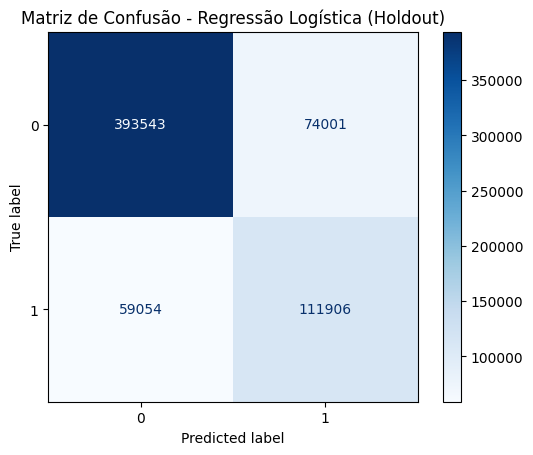

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Matriz de Confusão - Regressão Logística (Holdout)")
plt.show()

### Análise de Desempenho do Modelo: Matriz de Confusão (Regressão Logística - Holdout)

A avaliação da matriz de confusão obtida na base de validação (*Holdout*) permite mensurar a eficiência do classificador linear frente à dinâmica microestrutural do mercado preditivo:

| Classificação Real / Prevista | Previsto como Estável/Queda (0) | Previsto como Alta (1) |
| :--- | :---: | :---: |
| **Realmente Estável/Queda (0)** | **393.543** (Verdadeiro Negativo) | **74.001** (Falso Positivo) |
| **Realmente Alta (1)** | **59.054** (Falso Negativo) | **111.906** (Verdadeiro Positivo) |


#### Extração de Métricas de Performance

A partir dos dados brutos consolidados na matriz, extraem-se os seguintes indicadores estatísticos de performance global e de classe:

* **Acurácia Global (~79,16%):** O modelo classifica corretamente o estado do mercado em aproximadamente 79,2% dos minutos avaliados ($414.603$ acertos combinados sobre um espaço amostral total de $638.504$ observações). 
* **Precisão de Alta (~60,19%):** Quando o algoritmo emite um sinal preditivo de valorização (Classe 1), a assertividade observada é de 60,2% ($\frac{111.906}{111.906 + 74.001}$). Sob a ótica de trading, essa métrica delimita a taxa de acerto de ordens ativamente disparadas.
* **Sensibilidade / Recall de Alta (~65,46%):** O classificador consegue capturar e antecipar 65,5% de todas as janelas de alta que efetivamente ocorreram no histórico real do livro ($\frac{111.906}{111.906 + 59.054}$).


#### Conclusões

1. **Aderência ao Efeito Inércia:** O elevado volume de Verdadeiros Negativos ($393.543$) sinaliza que a Regressão Logística mapeou eficientemente a característica de estabilidade temporal do Polymarket. Como o livro de ordens passa a maior parte do tempo em equilíbrio ou flutuações laterais, o modelo linear discrimina bem estados de não-movimentação.
2. **Distribuição Controlada de Erros:** O volume de alarmes falsos (Falsos Positivos: $74.001$) supera moderadamente o montante de movimentos negligenciados (Falsos Negativos: $59.054$). Esse balanço indica uma leve tendência do modelo a reagir a ruídos de spread ou pequenas assimetrias do livro, convertendo-os em falsos gatilhos de momentum.
3. **Validação como Modelo Baseline:** Para uma abordagem linear paramétrica clássica operando sobre dados financeiros de alta frequência, o patamar de acurácia próximo a 80% e a precisão acima dos 60% estabelecem uma linha de base (*baseline*) robusta. Esse resultado justifica a transição subsequente para modelos baseados em árvores (como o LightGBM), os quais herdam essa separabilidade linear e refinam o aprendizado por meio de interações não-lineares complexas das features.

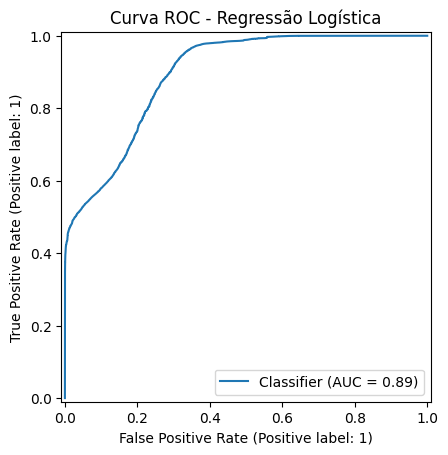

In [21]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_test
)

plt.title("Curva ROC - Regressão Logística")
plt.show()

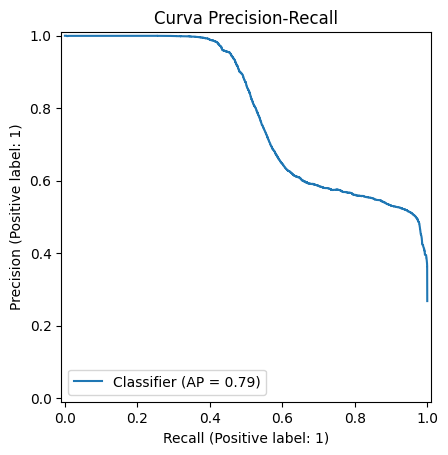

In [22]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba_test
)

plt.title("Curva Precision-Recall")
plt.show()

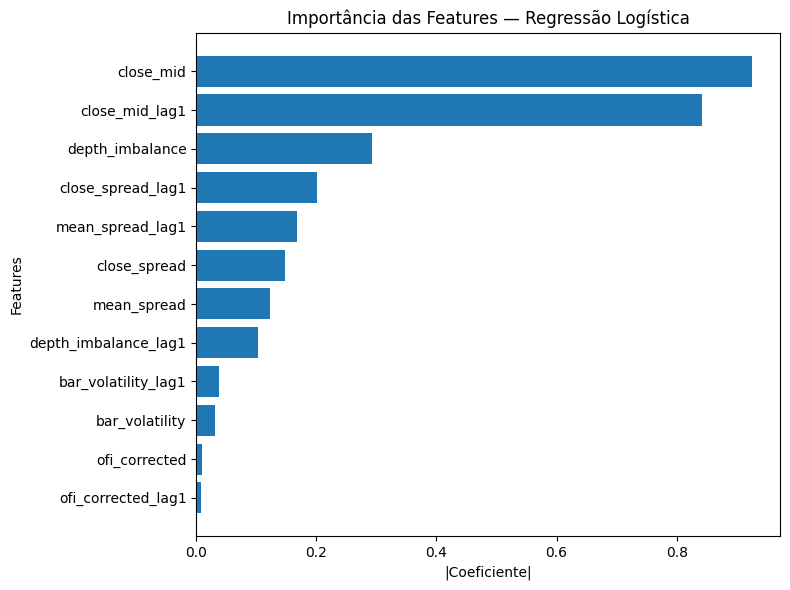

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Nomes das features
features = X_train.columns

# Coeficientes da regressão logística
coef = final_model.coef_[0]

# Importância = valor absoluto dos coeficientes
importance = np.abs(coef)

# Ordenação
order = np.argsort(importance)

# Gráfico
plt.figure(figsize=(8,6))
plt.barh(np.array(features)[order], importance[order])

plt.title("Importância das Features — Regressão Logística")
plt.xlabel("|Coeficiente|")
plt.ylabel("Features")

plt.tight_layout()
plt.show()